In [7]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import datetime
import pytz
NYC_tz = pytz.timezone("America/New_York") 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import sys
sys.path.append("../../")

import rateslib as rl
import QuantLib as ql

from Query.IRSwaps.IRSwapQuery import IRSwapQuery 
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapValue import IRSwapValue
from Query.IRSwaps.backends.rateslib.RLIRSwapCurve import RLIRSwapCurve

In [9]:
# curve_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
curve_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC-NOJUMPS")
# curve_mdp = IRSwapsMDP(source="citivelo")
# curve_mdp = IRSwapsMDP(source="BARCHART_STIRF-RL")

In [10]:
ts = "live"
# ts = NYC_tz.localize(datetime.datetime(2026, 7, 16, 17, 00))
curve = "USD-SOFR-1D"
# curve = "USD-SOFR-1D-Q12STIRT"
# curve = "USD-SOFR-1D-Q16STIRT"
# curve = "USD-SOFR-1D-Q20STIRT"
# curve = "USD-OIS-Q12xM12STIRT-SERFFX-MIX23"
# curve = "EUR-ESTR-NYC-Q12STIRT"
# curve = "CAD-CORRA-Q8STIRT"

curve_handle = curve_mdp.get_pricer(request=dict(curve_name=curve, timestamp=ts))
curve_handle

FETCHING ERIS INTRADAY DISC CURVE…: 100%|██████████| 1/1 [00:11<00:00, 11.22s/it]


RLIRSwapCurve(_rl_curve_id='USD-SOFR-1D', _rl_curve_handle=<rl.Curve:ERIS_EOD_LIVE-RL_BASIC-NOJUMPS-USD-SOFR-1D-live_nojumps-2026-07-23 18:53:05-04:00 at 0x15106097110>, _meta_data={'timestamp': datetime.datetime(2026, 7, 23, 18, 53, 5, tzinfo=<DstTzInfo 'America/New_York' EDT-1 day, 20:00:00 DST>), 'id': 'ERIS_EOD_LIVE-RL_BASIC-NOJUMPS-USD-SOFR-1D-live', 'requested_curve_name': 'USD-SOFR-1D', 'curve_name': 'USD-SOFR-1D', 'reference_curve_name': 'USD-SOFR-1D'})

(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x1510a35ee90>])

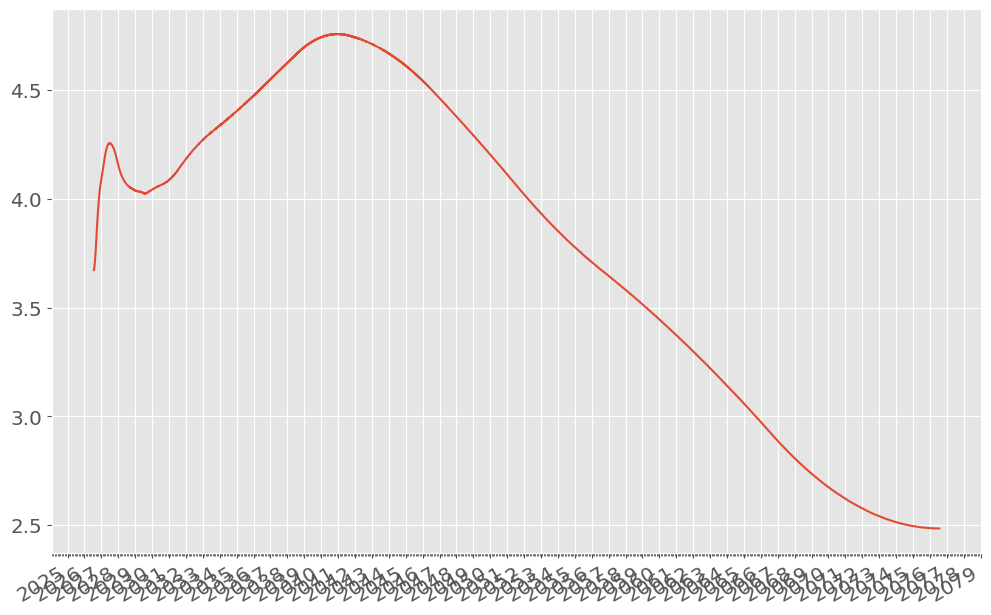

In [11]:
curve_handle.handle().plot("1d")

# Risk Model

In [12]:
risk_model_tenors = [
	# "fomc_1",
	# "fomc_2",
	# "fomc_3",
	# "fomc_4",
	# "fomc_5",
	# "fomc_6",
	# "fomc_7",
	
	"IMM_1xIMM_2",
    "IMM_2xIMM_3",
    "IMM_3xIMM_4",
    "IMM_4xIMM_5",
    "IMM_5xIMM_6",
    "IMM_6xIMM_7",
    "IMM_7xIMM_8",
    "IMM_8xIMM_9",
    "IMM_9xIMM_10",
    "IMM_10xIMM_11",
    "IMM_11xIMM_12",
    "IMM_12xIMM_13",
    
	# "IMM_13xIMM_14",
    # "IMM_14xIMM_15",
    # "IMM_15xIMM_16",
    # "IMM_16xIMM_17",

	# "IMM_17xIMM_18",
    # "IMM_18xIMM_19",
    # "IMM_19xIMM_20",
    # "IMM_20xIMM_21",
	# "4Y",	
    "5Y",
    # "6Y",
    # "7Y",
    # "8Y",
    # "9Y",
    "10Y",
    # "12Y",
    # "15Y",
    # "20Y",
    # "25Y",
    "30Y",
]

_dense_curve = curve_handle.handle()
_risk_pillar_nodes = {curve_handle.reference_date(): 1.0}
risk_par_rates = []
for t in risk_model_tenors:
    _q = IRSwapQuery(curve=curve, tenor=t).resolve_query(ts, pricer_or_curve=curve_handle)
    _pkg, _ = _q.resolve_package(pricer_or_curve=curve_handle)
    _irs = _pkg[0]
    risk_par_rates.append(_irs.rate().real)
    _mat = max(_irs.leg1.cashflows()["Acc End"])
    _risk_pillar_nodes[_mat] = float(_dense_curve[_mat])  # seed from dense curve

risk_rl_curve = rl.Curve(
    nodes=_risk_pillar_nodes,
    convention=_dense_curve.meta.convention,
    calendar=_dense_curve.meta.calendar,
    interpolation="log_linear",
    id=f"{curve_handle.id()}-RISK",
)
_risk_meta = dict(curve_handle.meta())
_risk_meta["id"] = f"{curve_handle.id()}-RISK"
risk_curve_handle = RLIRSwapCurve(
    rl_curve_id=f"{curve_handle.id()}-RISK",
    rl_curve_handle=risk_rl_curve,
    fixings=curve_handle.index(),
    meta_data=_risk_meta,
)

rl_risk_instruments = {}
for t in risk_model_tenors:
    outright_query = IRSwapQuery(curve=curve, tenor=t).resolve_query(ts, pricer_or_curve=risk_curve_handle)
    outright_pkg, _ = outright_query.resolve_package(pricer_or_curve=risk_curve_handle)
    rl_risk_instruments[t] = outright_pkg[0]

rl_risk_solver = rl.Solver(
    curves=[risk_rl_curve],
    instruments=rl_risk_instruments.values(),
    instrument_labels=rl_risk_instruments.keys(),
    s=risk_par_rates,
    id=f"{curve_handle.id()}-RISK",
    func_tol=1e-8,
    conv_tol=1e-10,
)

SUCCESS: `func_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 4.735191652179397e-09, `time`: 0.0151s


# Pricing

In [13]:
risk = 40_000
# tenor = "IMM_H27x1Y/IMM_H27x3Y/IMM_H27x5Y"
tenor = "IMM_3x1Y/IMM_3x3Y/IMM_3x5Y"
# tenor = "1y1y"
# tenor = "10y2y/12y3y/15y5y"
query = IRSwapQuery(curve=curve, tenor=tenor, structure_kwargs={"bpv": risk}).resolve_query(
    ts, pricer_or_curve=curve_handle
)
pkg, rws = query.resolve_package(pricer_or_curve=curve_handle)

vmap = query.build_value_map(pricer_or_curve=curve_handle, package=pkg, risk_weights=rws)
for v in [IRSwapValue.RATE, IRSwapValue.NPV, IRSwapValue.NOTIONAL, IRSwapValue.PV01]:
    print(v.name, vmap.apply(value=v))

i = 1
print(curve_handle.effective_date(pkg[i]))
print(curve_handle.maturity_date(pkg[i]))
print(f"{curve_handle.notional(pkg[i]):_.0f}")
# print(vmap.apply(value=IRSwapValue.CARRY_BPS_RUNNING, **{"horizon": "3m"}))
print(vmap.apply(value=IRSwapValue.ROLL_BPS_RUNNING, **{"horizon": "3m"}))

# Bucket risk must be priced on the calibrated risk curve, not the dense curve.
risk_pkg, _ = query.resolve_package(pricer_or_curve=risk_curve_handle)
display(rl.Portfolio(risk_pkg).delta(solver=rl_risk_solver).style.format("{:_.0f}"))

RATE -11.252014384777672
NPV -1.862645149230957e-09
NOTIONAL -110127759.04827315
PV01 0.0
2027-03-17 00:00:00
2030-03-18 00:00:00
146_479_695
-0.34905002924960626


In [36]:
# Bucket risk must be priced on the calibrated risk curve, not the dense curve.
query1 = IRSwapQuery(curve=curve, tenor="3m2y/3m30y", structure_kwargs={"bpv": -100_000}).resolve_query(
    ts, pricer_or_curve=risk_curve_handle
)
pkg1, _= query1.resolve_package(pricer_or_curve=risk_curve_handle)

query2 = IRSwapQuery(curve=curve, tenor="2y2y/2y30y", structure_kwargs={"bpv": 100_000}).resolve_query(
    ts, pricer_or_curve=risk_curve_handle
)
pkg2, _= query2.resolve_package(pricer_or_curve=risk_curve_handle)

# book = rl.Portfolio(pkg1 + pkg2)
book = rl.Portfolio(pkg1)
display(book.delta(solver=rl_risk_solver).style.format("{:_.0f}"))

## Fwd Grid (useful for swaptions)

In [9]:
grid = curve_mdp.get_grid(
    {
        "curve_name": curve,
        "timestamp": ts,
    },
)
grid

forward_tenor,Spot,1M,3M,6M,1Y,2Y,5Y,7Y,10Y
swap_tenor,,,,,,,,,
1Y,3.802582,3.810085,3.814675,3.791337,3.649254,3.546131,3.931344,3.931132,3.931132
2Y,3.725838,3.717860,3.697931,3.664773,3.598533,3.608873,3.931240,3.931340,3.931132
3Y,3.668205,3.665527,3.658354,3.645948,3.622828,3.688369,3.931205,3.931206,3.931132
4Y,3.669798,3.670664,3.671356,3.672507,3.678033,3.745760,3.931288,3.931189,3.931283
5Y,3.704717,3.707702,3.712943,3.718443,3.724986,3.779999,3.931221,3.931178,3.931216
7Y,3.763634,3.765754,3.769528,3.773745,3.778289,3.819184,3.931198,3.931247,3.931166
8Y,3.781779,3.783675,3.787236,3.790783,3.795024,3.831282,3.931191,3.931212,3.931186
9Y,3.795868,3.797642,3.800801,3.804014,3.807843,3.840721,3.931245,3.931184,3.931181
10Y,3.807206,3.808828,3.811677,3.814664,3.818123,3.848256,3.931218,3.931180,3.931212


# Fwd Curve

In [ ]:
fwd_tenor = "1y"
x_data_num, y_data_rate = curve_handle.handle()._plot_rates(fwd_tenor, left=rl.NoInput(0), right=rl.NoInput(0))
plot_data_dict = dict(zip(x_data_num, [y.real for y in y_data_rate]))

calendar = ql.UnitedStates(ql.UnitedStates.FederalReserve)
filtered_plot_data = {dt: rate for dt, rate in plot_data_dict.items() if calendar.isBusinessDay(ql.Date(dt.day, dt.month, dt.year))}

x_business_days = list(filtered_plot_data.keys())
y_business_rates = list(filtered_plot_data.values())
curve_nodes = curve_handle.handle().nodes._nodes.keys()

# fig, ax = plt.subplots()
# ax.plot(x_business_days, y_business_rates)
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# plt.xticks(rotation=45, ha="right")  # Rotate ticks for better readability
# ax.grid(True, linestyle="--", alpha=0.6)

# ticks = [t.tz_localize(None) if getattr(t, "tzinfo", None) else t for t in curve_nodes]
# ax.set_xticks(mdates.date2num(ticks))
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# plt.title(f"{curve_handle.meta()["id"]} | {curve_handle.meta()["timestamp"]} | 1d")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


fig = go.Figure()
fig.add_trace(go.Scatter(x=x_business_days, y=y_business_rates, mode="lines", name="1D"))

tick_vals = [pd.Timestamp(t).tz_localize(None) for t in curve_nodes]
tick_text = [pd.Timestamp(t).strftime("%Y-%m-%d") for t in tick_vals]

fig.update_layout(
    title=f"{curve_handle.meta()["id"]} | {curve_handle.meta()["timestamp"]} | 1d curve",
    template="plotly_dark",
    margin=dict(l=40, r=20, t=60, b=80),
    xaxis=dict(tickmode="array", tickvals=tick_vals, ticktext=tick_text, tickangle=45, showgrid=True),
    height=550,
    # width=1200,
    yaxis=dict(showgrid=True),
)
fig.update_xaxes(
    showspikes=True,
    spikecolor="white",
    spikesnap="cursor",
    spikemode="across",
    showgrid=True,
)
fig.update_yaxes(
    showspikes=True,
    spikecolor="white",
    spikesnap="cursor",
    spikethickness=0.5,
    showgrid=True,
)

fig.show()

## Paid GBP vs CAD 1y1y  

In [ ]:
from MDP.IRSwaps.BARCHART_STIRF.rl import BARCHART_STIRF_CURVE, plot_overnight_forward_curves

LDN_tz = pytz.timezone("Europe/London") 

bc_stirf_curve = BARCHART_STIRF_CURVE()

plot_overnight_forward_curves(
	curves=[
		# bc_stirf_curve.build_curve(
		# 	curve_name="USD-OIS-Q12xM12STIRT-SERFFX",
		# 	timestamp=NY_tz.localize(datetime.datetime(2026, 3, 11, 17, 00)),
		# 	# kwargs={"force_refresh": True, "cache_full_intraday_fetch": True},

		# ),
		bc_stirf_curve.build_curve(
			curve_name="CAD-CORRA-Q8STIRT",
			timestamp="live",
			# timestamp=LDN_tz.localize(datetime.datetime(2026, 3, 23, 17, 00)),
		),
		bc_stirf_curve.build_curve(
			curve_name="GBP-SONIA-Q12STIRT",
			timestamp="live",
			# timestamp=LDN_tz.localize(datetime.datetime(2026, 3, 23, 17, 00)),
		),
		bc_stirf_curve.build_curve(
			curve_name="CAD-CORRA-Q8STIRT",
			timestamp=LDN_tz.localize(datetime.datetime(2026, 3, 20, 17, 00)),
		),
		bc_stirf_curve.build_curve(
			curve_name="GBP-SONIA-Q12STIRT",
			timestamp=LDN_tz.localize(datetime.datetime(2026, 3, 20, 17, 00)),
		),
        # bc_stirf_curve.build_curve(
		# 	# curve_name="USD-OIS-Q12xM12STIRT-SERFFX",
		# 	curve_name="USD-SOFR-1D-Q12STIRT",
		# 	timestamp=NY_tz.localize(datetime.datetime(2025, 8, 1,  17, 00)),
		# 	# kwargs={"force_refresh": True, "cache_full_intraday_fetch": True},
		# ),
        # bc_stirf_curve.build_curve(
		# 	curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
			# timestamp=NY_tz.localize(datetime.datetime(2026, 3, 11, 17, 00)),
		# 	# kwargs={"force_refresh": True, "cache_full_intraday_fetch": True},

		# ),
		# bc_stirf_curve.build_curve(
		# 	curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
		# 	# timestamp=NY_tz.localize(datetime.datetime(2026, 3, 12, 17, 00)),
		# 	timestamp="live",
		# 	# kwargs={"force_refresh": True, "cache_full_intraday_fetch": True},
		# ),
		# bc_stirf_curve.build_curve(
		# 	curve_name="USD-SOFR-1D-Q12STIRT",
		# 	timestamp=NY_tz.localize(datetime.datetime(2023, 3, 10, 17, 00)),
		# ),
		# bc_stirf_curve.build_curve(
		# 	curve_name="USD-SOFR-1D-Q12STIRT",
		# 	timestamp=NY_tz.localize(datetime.datetime(2023, 3, 13, 7, 00)),
		# ),
		# bc_stirf_curve.build_curve(
		# 	curve_name="USD-SOFR-1D-Q12STIRT",
		# 	timestamp=NY_tz.localize(datetime.datetime(2023, 3, 13, 17, 00)),
		# ),
	]
)

In [12]:
curve_mdp = IRSwapsMDP(source="BARCHART_STIRF-RL")
cad_curve_handle = curve_mdp._get_curve(curve_name="CAD-CORRA-Q8STIRT", timestamp="live")
gbp_curve_handle = curve_mdp._get_curve(curve_name="GBP-SONIA-Q12STIRT", timestamp="live")

In [13]:
risk = 100_000
cad_query = IRSwapQuery(curve="CAD-CORRA-Q8STIRT", tenor="1y1y", structure_kwargs={"bpv": risk}).resolve_query("live", pricer_or_curve=cad_curve_handle)
cad_pkg, cad_rws = cad_query.resolve_package(pricer_or_curve=cad_curve_handle)
cad_vmap = cad_query.build_value_map(pricer_or_curve=cad_curve_handle, package=cad_pkg, risk_weights=cad_rws)

gbp_query = IRSwapQuery(curve="CAD-CORRA-Q8STIRT", tenor="1y1y", structure_kwargs={"bpv": risk}).resolve_query("live", pricer_or_curve=cad_curve_handle)
gbp_pkg, gbp_rws = gbp_query.resolve_package(pricer_or_curve=gbp_curve_handle)
gbp_vmap = gbp_query.build_value_map(pricer_or_curve=gbp_curve_handle, package=gbp_pkg, risk_weights=gbp_rws)

(gbp_vmap.apply(value=IRSwapValue.RATE) - cad_vmap.apply(value=IRSwapValue.RATE)) * 100

133.5410778717166

In [100]:
gbp_vmap.apply(value=IRSwapValue.ROLL_BPS_RUNNING, **{"horizon": "3m"}), cad_vmap.apply(value=IRSwapValue.RATE, **{"horizon": "3m"})

(-2.7914064572329838, 3.073347612689848)